# Data Exploratory Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
df = pd.read_excel('INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls')

In [3]:
df

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,...,2,6,3,3,6,5,0,4,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,...,1,4,2,3,1,0,0,0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,...,3,20,3,3,20,8,3,8,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,...,2,9,3,4,8,7,7,7,No,3


In [4]:
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [5]:
df.tail()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,...,2,6,3,3,6,5,0,4,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,...,1,4,2,3,1,0,0,0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,...,3,20,3,3,20,8,3,8,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,...,2,9,3,4,8,7,7,7,No,3
1199,E100998,24,Female,Life Sciences,Single,Sales,Sales Executive,Travel_Rarely,3,2,...,1,4,3,3,2,2,2,0,Yes,2


In [6]:
df.shape

(1200, 28)

In [7]:
df.columns

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

In [8]:
# New Dataframe is created to analyze department wise performance.
dept = df.iloc[:,[5,27]].copy()
dept_per = dept.copy()

In [9]:
target = "PerformanceRating"


In [10]:
# Finding the mean performance of all the departments and plotting bar graph using seaborn.
dept_per.groupby(by='EmpDepartment')['PerformanceRating'].mean()

EmpDepartment
Data Science              3.050000
Development               3.085873
Finance                   2.775510
Human Resources           2.925926
Research & Development    2.921283
Sales                     2.860590
Name: PerformanceRating, dtype: float64

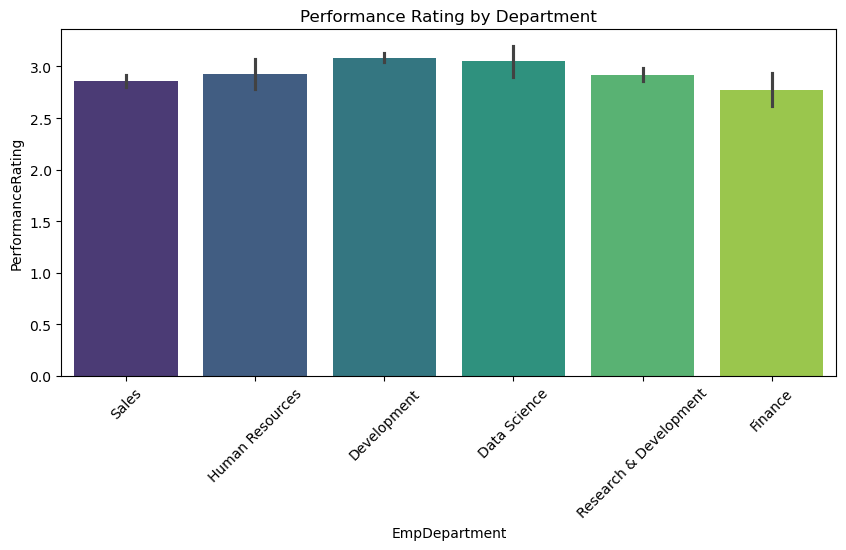

In [11]:
plt.figure(figsize=(10,4.5))
sns.barplot(x='EmpDepartment', y='PerformanceRating', hue='EmpDepartment',data=dept_per,palette='viridis',legend=False)
plt.xticks(rotation=45)
plt.title("Performance Rating by Department")
plt.show()

###  Insights: Performance Rating by Department

- **Development** department shows the **highest average performance rating (~3.1)**, indicating strong productivity and effective alignment of skills and job roles.

- **Data Science** department also demonstrates **above-average performance (~3.05)**, suggesting a well-performing team with good job-role fit and effective work processes.

- **Sales** and **Finance** departments record the **lowest average performance ratings (~2.88 and ~2.78 respectively)**.  
  - These areas may require targeted interventions such as:
    - Additional training programs  
    - Improved motivation or incentive mechanisms  
    - Better workload distribution  
    - Review of managerial practices  

- **Human Resources** and **Research & Development** exhibit **moderate and stable performance (~2.93–2.95)**, with no significant fluctuations.

- Overall, the performance ratings across departments fall within a **narrow range (2.7 – 3.1)**, indicating organizational stability.  
  - However, the slight differences highlight **specific departments that can benefit from focused performance improvement initiatives**.


In [12]:
# Analyze all department separately
dept_per.groupby(by='EmpDepartment')['PerformanceRating'].value_counts()

EmpDepartment           PerformanceRating
Data Science            3                     17
                        4                      2
                        2                      1
Development             3                    304
                        4                     44
                        2                     13
Finance                 3                     30
                        2                     15
                        4                      4
Human Resources         3                     38
                        2                     10
                        4                      6
Research & Development  3                    234
                        2                     68
                        4                     41
Sales                   3                    251
                        2                     87
                        4                     35
Name: count, dtype: int64

In [13]:
# Creating new Dataframe to analyze each department separately
department = pd.get_dummies(dept_per['EmpDepartment'])
performance = pd.DataFrame(dept_per['PerformanceRating'])
dept_rating = pd.concat([department,performance],axis=1)

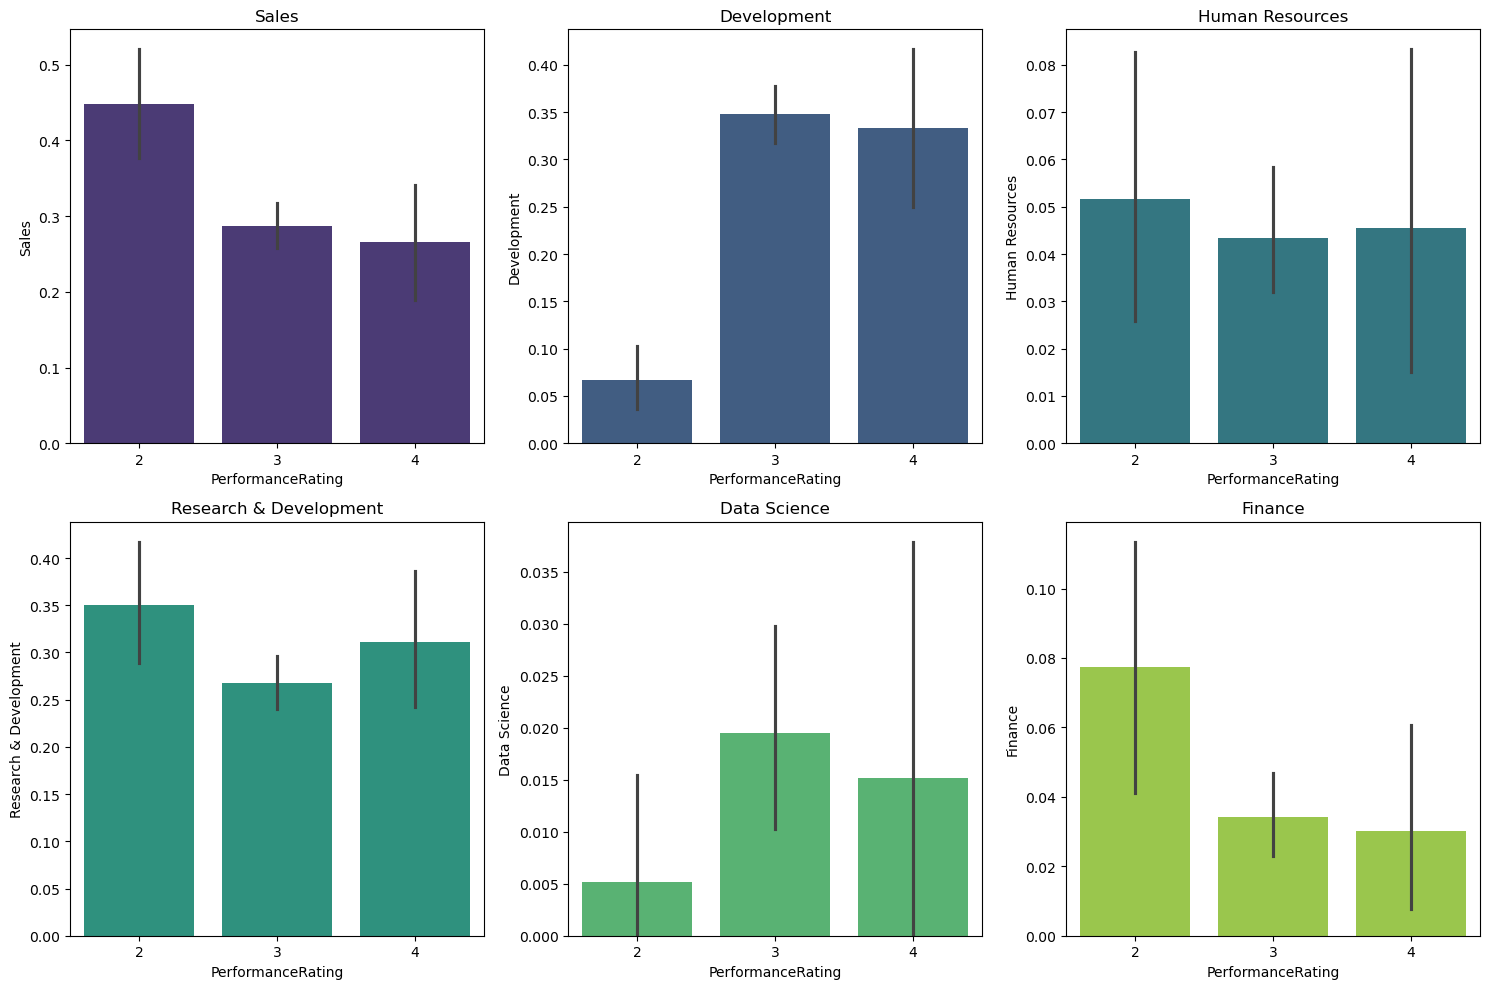

In [14]:
plt.figure(figsize=(15,10))
colors = sns.color_palette("viridis", 6)
# 1 Sales
plt.subplot(2,3,1)
sns.barplot(x='PerformanceRating', y='Sales', data=dept_rating, color=colors[0])
plt.title("Sales")

# 2 Development
plt.subplot(2,3,2)
sns.barplot(x='PerformanceRating', y='Development', data=dept_rating, color=colors[1])
plt.title("Development")

# 3 Human Resources
plt.subplot(2,3,3)
sns.barplot(x='PerformanceRating', y='Human Resources', data=dept_rating, color=colors[2])
plt.title("Human Resources")

# 4 Research & Development
plt.subplot(2,3,4)
sns.barplot(x='PerformanceRating', y='Research & Development', data=dept_rating, color=colors[3])
plt.title("Research & Development")

# 5 Data Science
plt.subplot(2,3,5)
sns.barplot(x='PerformanceRating', y='Data Science', data=dept_rating, color=colors[4])
plt.title("Data Science")

# 6 Finance
plt.subplot(2,3,6)
sns.barplot(x='PerformanceRating', y='Finance', data=dept_rating, color=colors[5])
plt.title("Finance")

plt.tight_layout()
plt.show()


### Insights: Performance Rating Distribution Across Departments

#### **1. Sales**
- Highest proportion of employees fall under **Rating 2**.
- Very few reach Ratings **3 or 4**.
- **Insight:** Sales needs performance improvement initiatives such as skill development, better targets, or improved incentive structure.

#### **2. Development**
- Majority of employees belong to **Ratings 3 and 4**.
- Very few low performers.
- **Insight:** Development is a top-performing department with consistent results.

#### **3. Human Resources**
- Distribution across Ratings **2, 3, and 4** is relatively even.
- **Insight:** HR shows stable but moderate performance with no extremes.

#### **4. Research & Development (R&D)**
- Slight skew toward **Rating 2**, but Ratings **3 and 4** are also present.
- **Insight:** R&D performance is average; improvements in project execution may help.

#### **5. Data Science**
- Majority of employees fall under **Ratings 3 and 4**.
- Very few low performers (Rating 2).
- **Insight:** Data Science is a high-performing team with strong capability.

#### **6. Finance**
- Highest share of employees under **Rating 2**.
- Few employees reach higher ratings.
- **Insight:** Finance is a lower-performing department and may require process optimization or training programs.

---

###  Overall Summary
- **Best-performing departments:** Development, Data Science  
- **Lowest-performing departments:** Sales, Finance  
- **Moderate performance:** HR, Research & Development  


In [15]:
num_df = df.select_dtypes(include=['int64', 'float64'])
num_df.columns


Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'PerformanceRating'],
      dtype='object')

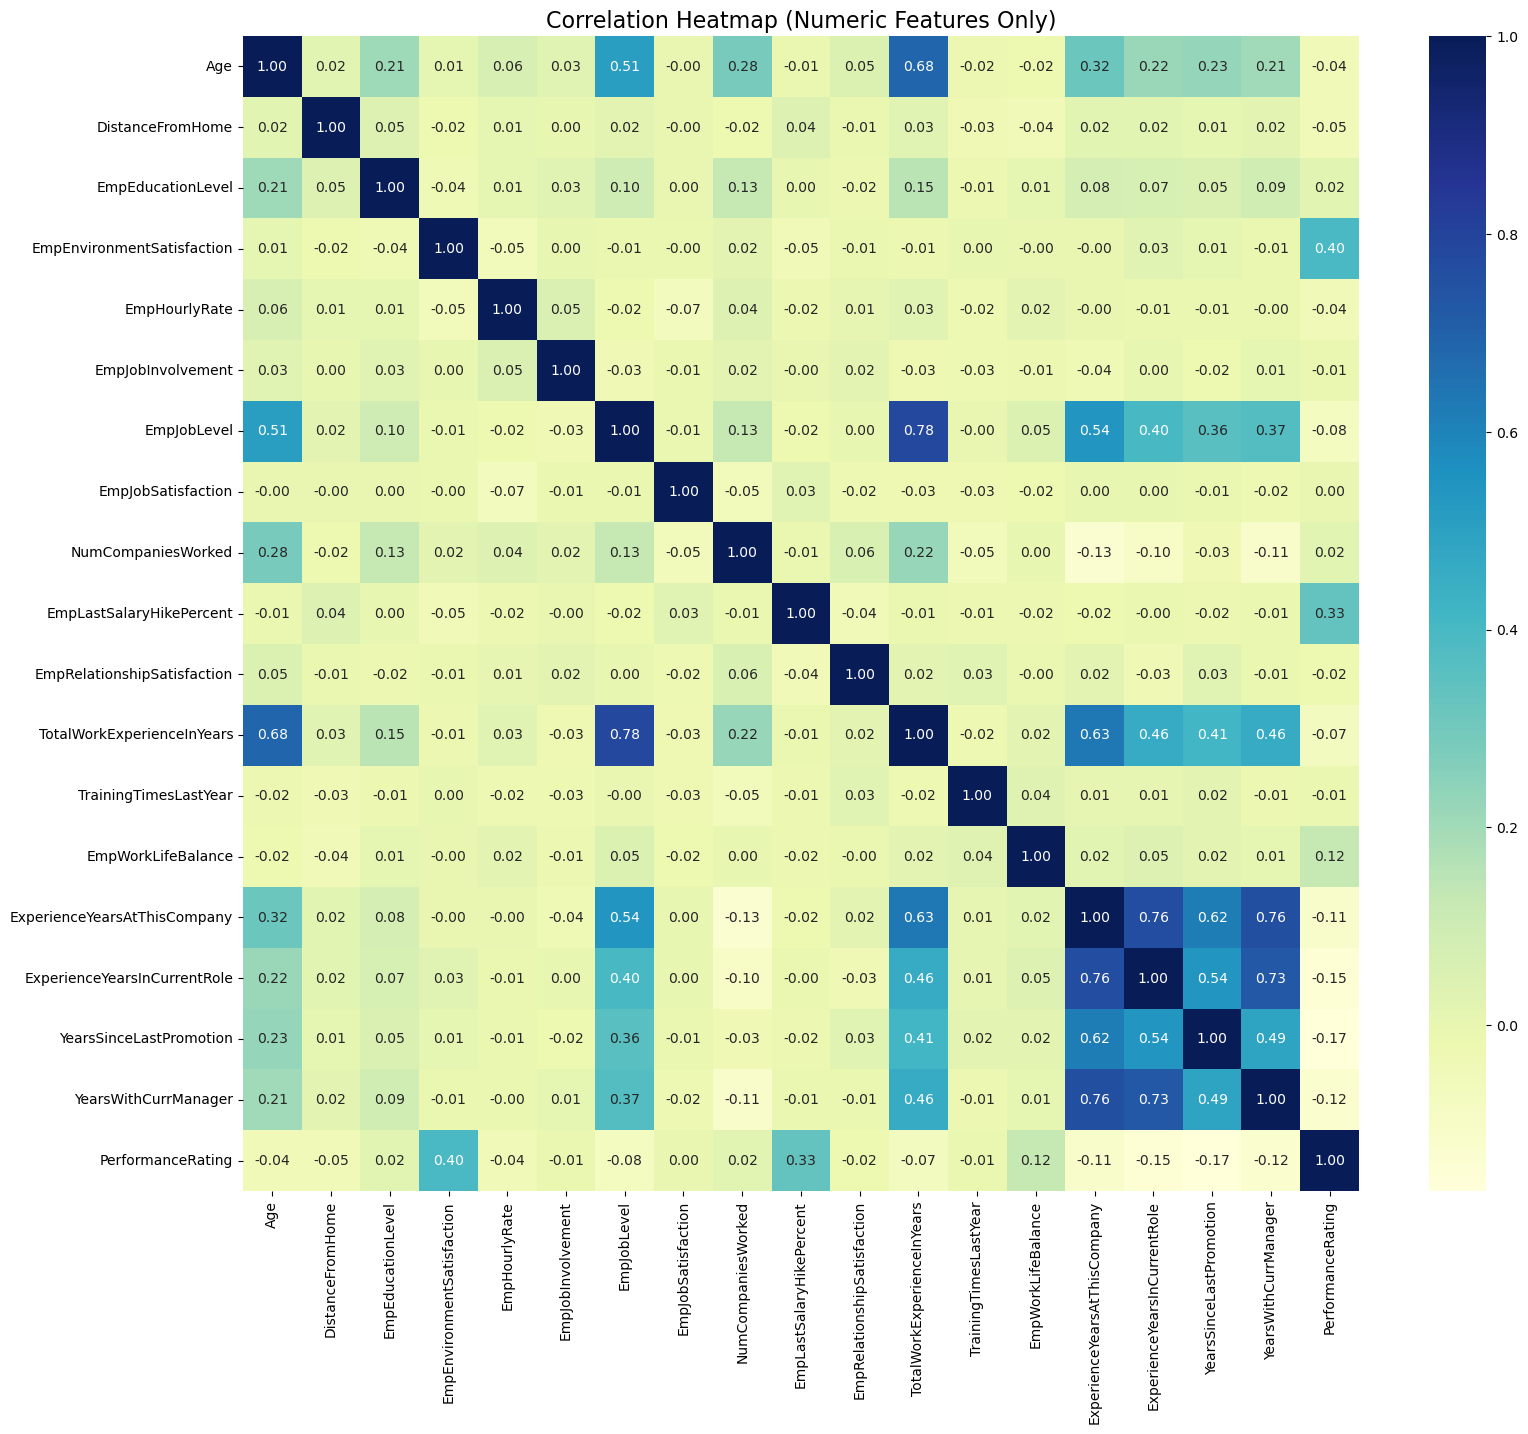

In [16]:
plt.figure(figsize=(18,15))
sns.heatmap(num_df.corr(), cmap='YlGnBu', annot=True, fmt='.2f')
plt.title("Correlation Heatmap (Numeric Features Only)", fontsize=16)
plt.show()


##  Correlation Heatmap Insights

### **1. Weak overall correlation with Performance Rating**
Most numeric features show low correlation values with **PerformanceRating**, indicating that employee performance is influenced by several small factors rather than a single dominant variable. This supports the need for a nonlinear model such as Random Forest.

---

### **2. Features with noticeable relationships to Performance Rating**

####  **EmpEnvironmentSatisfaction (0.40)**
Employees who report higher environment satisfaction generally have better performance ratings. This is one of the strongest positive correlations in the dataset.

####  **EmpLastSalaryHikePercent (0.33)**
There is a moderate positive relationship between salary hike percentage and performance. Employees rewarded with higher salary hikes tend to perform better.

####  **YearsSinceLastPromotion (−0.17)**
A weak but meaningful negative correlation. Employees who have not been promoted for a long time may experience performance decline.

---

### **3. Strong correlations among experience-related variables**
Several tenure-based features are highly correlated with each other:

- `ExperienceYearsAtThisCompany` ↔ `YearsWithCurrManager` (0.76)  
- `ExperienceYearsInCurrentRole` ↔ `YearsWithCurrManager` (0.73)  
- `ExperienceYearsAtThisCompany` ↔ `ExperienceYearsInCurrentRole` (0.62)  
- `TotalWorkExperienceYears` ↔ `Age` (0.68)

These reflect redundancy. They capture similar concepts of tenure and experience.

---

### **4. Job Level is strongly related to experience**
- `EmpJobLevel` shows a strong correlation (0.78) with `TotalWorkExperienceYears`.

This suggests that employees with more years of experience typically attain higher job levels, confirming dataset consistency.

---

### **5. No risk of target multicollinearity**
Since **PerformanceRating** does not heavily correlate with any single numeric variable, it reduces the risk of linear dependency.  
Tree-based models like Random Forest are appropriate for capturing complex interactions in such scenarios.

---

### **6. Satisfaction and recognition factors show meaningful influence**
Although correlations are moderate, variables such as:

- Work environment satisfaction  
- Salary hike percentage  
- Promotion timing  

show clearer relationships with performance than tenure or demographic variables.

---

###  **Summary**
The heatmap shows that employee performance is moderately influenced by:

- Salary hike percentage  
- Work environment satisfaction  
- Promotion frequency  

Meanwhile, many experience-related variables are highly correlated with each other, indicating overlapping information.  
This analysis validates using **non-linear models** and **feature importance** techniques rather than relying solely on correlations.


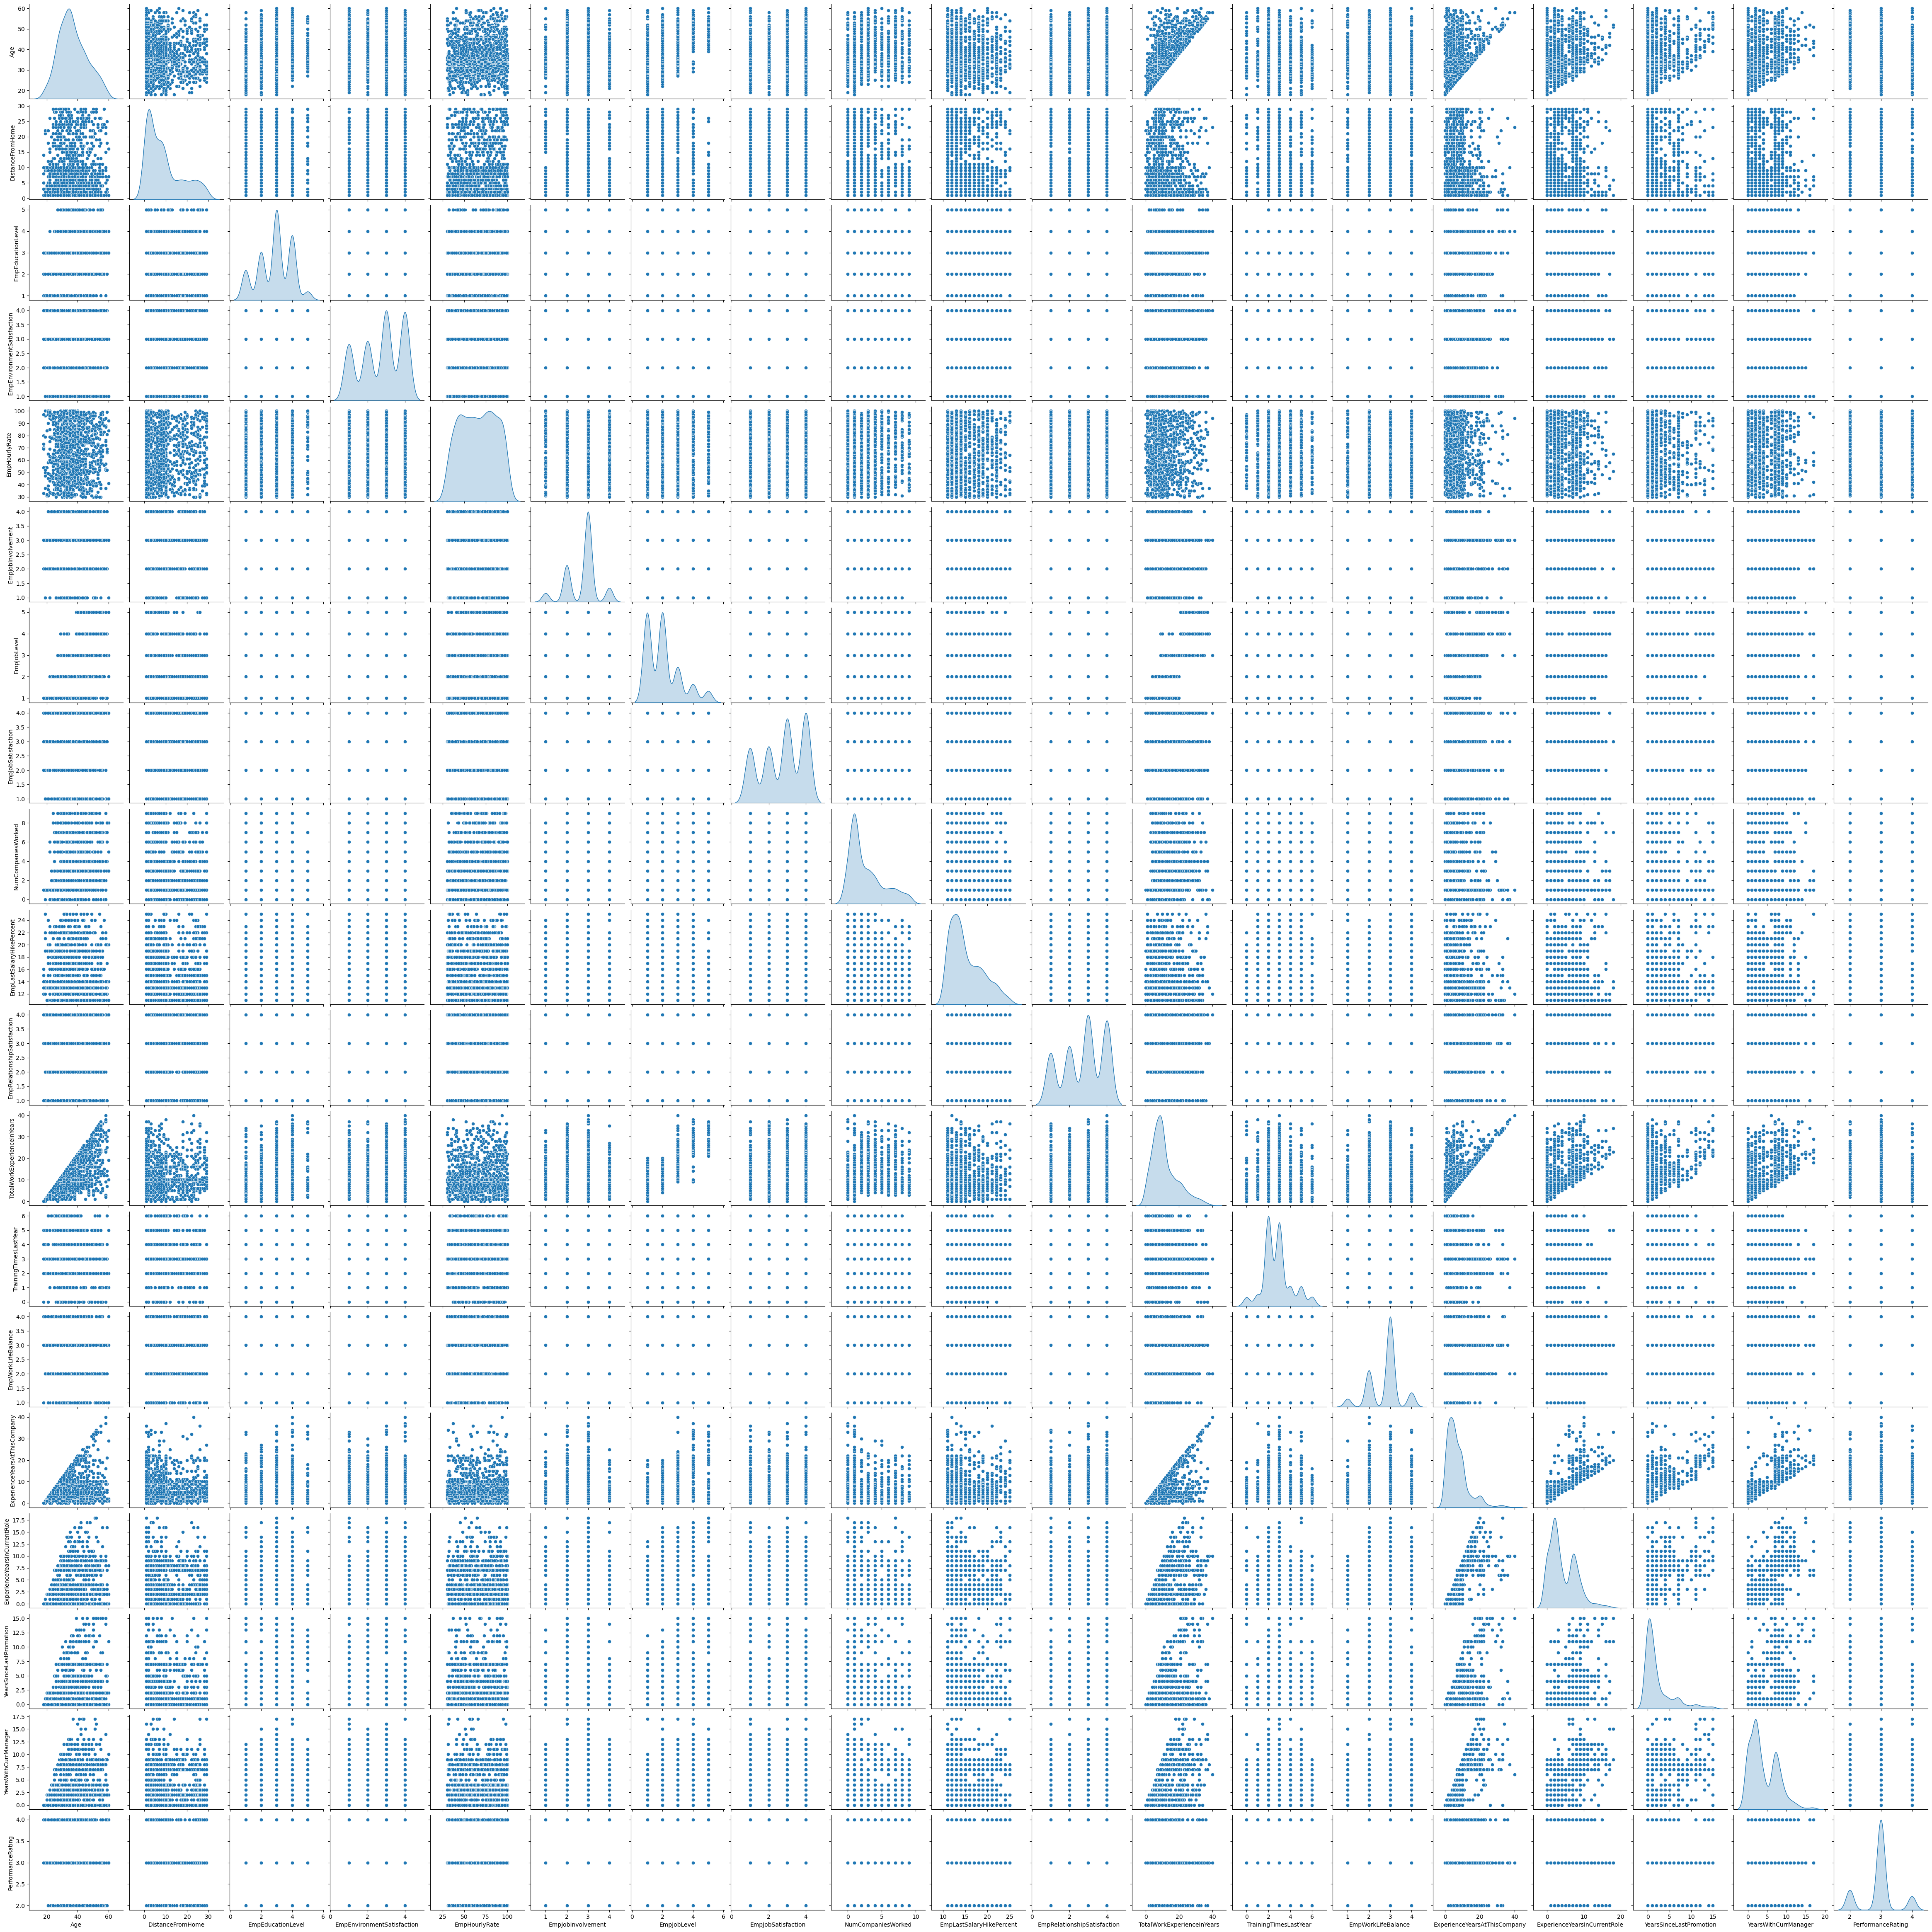

In [17]:
sns.pairplot(df, diag_kind='kde')